# AirBnb Listings Analysis

### Objective 1: Profile & QA the data

In [113]:
# Import/Open data set file
import pandas as pd

listings = pd.read_csv('/Users/alvintpham/Downloads/Python Projects/Airbnb Data/Listings.csv',
                       encoding = 'latin-1', 
                       low_memory = False)

In [114]:
# Understanding the data set
listings.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [115]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [116]:
# Cast any date columns as a datetime format
listings["host_since"] = pd.to_datetime(listings["host_since"])

listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

In [117]:
# Filter the data down to rows where the city is Paris, and keep columns ‘host_since’, ‘neighbourhood’, ‘city’, ‘accommodates’, and ‘price’
paris_listings = (
    listings
    .query("city == 'Paris'")
    .loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]]
)

paris_listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   neighbourhood  64690 non-null  object        
 2   city           64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


In [118]:
# Checking for missing values, and calculate the minimum, maximum, and average for each numeric field
paris_listings.isna().sum()

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [119]:
paris_listings.describe()

,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867584,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [120]:
paris_listings.query("accommodates == 0").count()

host_since       54
neighbourhood    54
city             54
accommodates     54
price            54
dtype: int64

In [121]:
paris_listings.query("price == 0").count()

host_since       62
neighbourhood    62
city             62
accommodates     62
price            62
dtype: int64

In [122]:
paris_listings.query("price == 0 and accommodates == 0").count()

host_since       54
neighbourhood    54
city             54
accommodates     54
price            54
dtype: int64

### Objective 2: Prepare for Visualization

In [124]:
# Group Paris listings by "neighbourhood" and calculates the mean price (sorted low to high)
paris_listings_neighbourhood = (
    paris_listings
    .groupby("neighbourhood")
    .agg({"price": "mean"})
    .sort_values("price")
)

paris_listings_neighbourhood.head()

,price
neighbourhood,
Menilmontant,74.942257
Buttes-Chaumont,82.690182
Buttes-Montmartre,87.209479
Reuilly,89.058402
Popincourt,90.559459


In [125]:
paris_listings_neighbourhood.tail()

,price
neighbourhood,
Luxembourg,155.638639
Palais-Bourbon,156.856578
Passy,161.144635
Louvre,175.379972
Elysee,210.536765


In [126]:
# Filtering to the most expensive neighborhood, group by the "accommodations" column, add the mean price for each value of "accommodates"
paris_listings_accommodates = (
    paris_listings
    .query("neighbourhood == 'Elysee'")
    .groupby("accommodates")
    .agg({"price" : "mean", "neighbourhood" : "count"})
    .sort_values("price")
)

paris_listings_accommodates.head()

,price,neighbourhood
accommodates,,
0,0.000000,6
1,79.522222,90
3,152.828767,146
2,155.103352,716
4,212.096070,458


In [127]:
paris_listings_accommodates.tail()

,price,neighbourhood
accommodates,,
12,529.625,8
16,800.000,1
11,805.000,4
13,842.500,2
14,971.000,2


In [128]:
paris_listings_accommodates = (
    paris_listings
    .query("neighbourhood == 'Elysee'")
    .groupby("accommodates")
    .agg({"price" : "mean"})
    .sort_values("price")
)

paris_listings_accommodates.head()

,price
accommodates,
0,0.000000
1,79.522222
3,152.828767
2,155.103352
4,212.096070


In [129]:
# Group by the ‘host_since’ year, calculate the average price, and count of rows representing the number of new hosts
paris_listings_over_time = (
    paris_listings
    .set_index("host_since")
    .resample("YE")
    .agg({
        "neighbourhood": "count",
        "price": "mean"
    })
)

paris_listings_over_time.head()

,neighbourhood,price
host_since,,
2008-12-31,4,77.750000
2009-12-31,106,159.641509
2010-12-31,416,125.031250
2011-12-31,1339,124.828230
2012-12-31,4592,111.578615


### Objective 3: Visualize the data and summarize findings

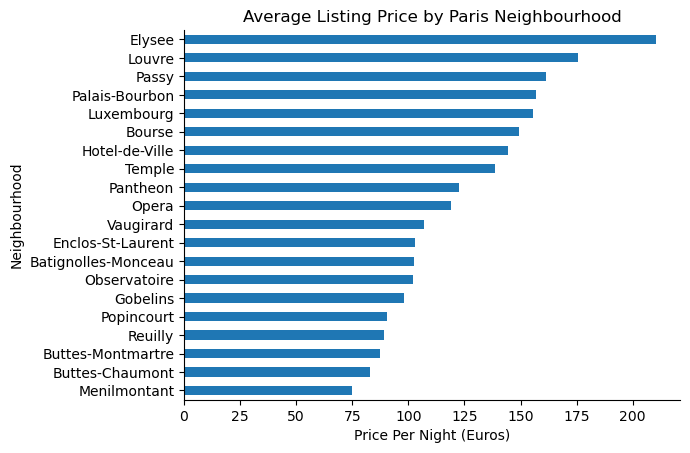

In [130]:
# Horizontal bar chart of the average price by neighborhood in Paris
import seaborn as sns

(paris_listings_neighbourhood
    .plot
    .barh(
        title="Average Listing Price by Paris Neighbourhood",
        xlabel="Price Per Night (Euros)",
        ylabel="Neighbourhood",
        legend=None
    )
)

sns.despine()

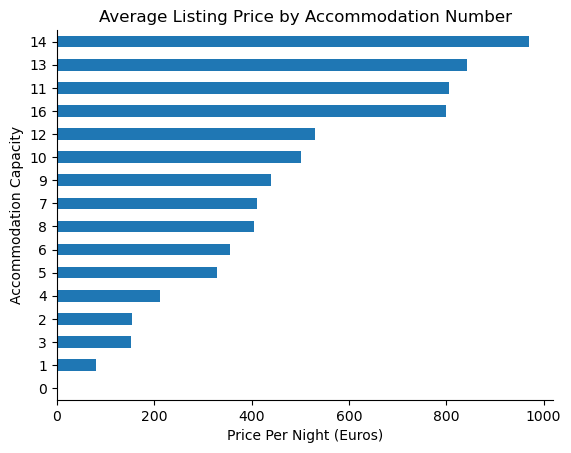

In [131]:
# Horizontal bar chart of the average price by "accommodates" in Paris' most expensive neighborhood
(paris_listings_accommodates
    .plot
    .barh(
        title="Average Listing Price by Accommodation Number",
        xlabel="Price Per Night (Euros)",
        ylabel="Accommodation Capacity",
        legend=None
    )
)

sns.despine()

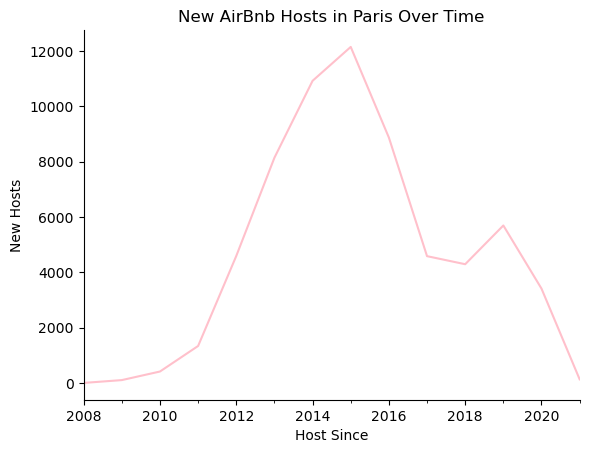

In [132]:
# Line chart showing the count of new hosts over time
paris_listings_over_time["neighbourhood"].plot(
    xlabel="Host Since",
    ylabel="New Hosts",
    title="New AirBnb Hosts in Paris Over Time",
    c="pink"
)

sns.despine()

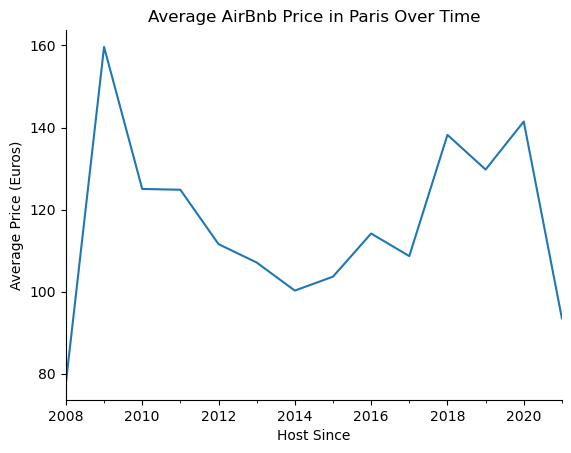

In [133]:
# Line chart showing average price over time
paris_listings_over_time["price"].plot(
    xlabel="Host Since",
    ylabel="Average Price (Euros)",
    title="Average AirBnb Price in Paris Over Time"
)

sns.despine()

Text(0.5, 1.0, 'Paris Airbnb Hosts and Prices Throughout the Years')

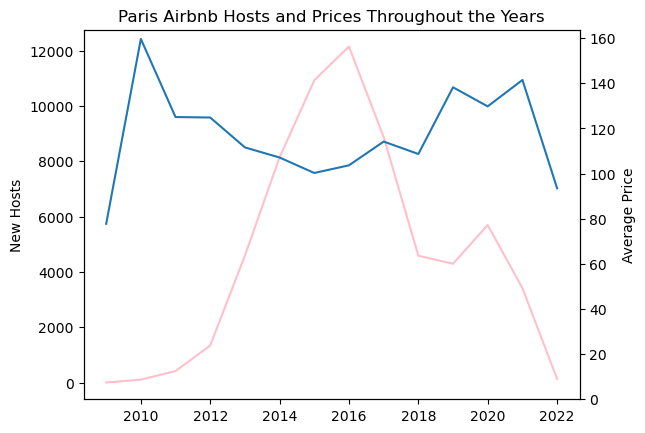

In [134]:
# Dual axis line chart to show both new hosts and average price over time
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(
    paris_listings_over_time.index,
    paris_listings_over_time["neighbourhood"],
    label="New Hosts",
    c="pink"
)

ax.set_ylabel("New Hosts")

ax2 = ax.twinx()

ax2.plot(
    paris_listings_over_time.index,
    paris_listings_over_time["price"],
    label="Average Price"
)
ax2.set_ylim(0)

ax2.set_ylabel("Average Price")

ax.set_title("Paris Airbnb Hosts and Prices Throughout the Years")

#### Based on the data, Airbnb prices in Paris were elevated during the platform's early years when the number of hosts was limited. As host growth increased throughout the years, prices declined likely due to increased competition among listings. Conversely, periods of fewer hosts correlated with higher average prices, reflecting reduced supply. Notably, both new hosts and average prices experienced a sharp decline during the COVID-19 period, consistent with the broader impact of the pandemic on the short-term rental market. 